In [1]:
import os

cropped_base = "../dataset/cropped"

classes = ["glioma", "meningioma", "pituitary"]

for class_name in classes:
    os.makedirs(
        os.path.join(cropped_base, class_name),
        exist_ok=True
    )

print("Cropped dataset folders created.")

Cropped dataset folders created.


In [2]:
import os
import cv2
import imutils

In [3]:
def crop_brain_contour(image):
    
    # 1. Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Gaussian Blur
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Threshold
    thresh = cv2.threshold(
        gray,
        45,
        255,
        cv2.THRESH_BINARY
    )[1]

    # 4. Erosion
    thresh = cv2.erode(
        thresh,
        None,
        iterations=2
    )

    # 5. Dilation
    thresh = cv2.dilate(
        thresh,
        None,
        iterations=2
    )

    # 6. Find contours
    cnts = cv2.findContours(
        thresh.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cnts = imutils.grab_contours(cnts)

    # 7. Select largest contour
    c = max(cnts, key=cv2.contourArea)

    # 8. Find extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # 9. Crop ORIGINAL image
    new_image = image[
        extTop[1]:extBot[1],
        extLeft[0]:extRight[0]
    ]

    return new_image

In [4]:
processed_base = "../dataset/processed"
cropped_base = "../dataset/cropped"

classes = [
    "glioma",
    "meningioma",
    "pituitary"
]

total = 0
failed = 0

for class_name in classes:

    input_folder = os.path.join(
        processed_base,
        class_name
    )

    output_folder = os.path.join(
        cropped_base,
        class_name
    )

    for filename in os.listdir(input_folder):

        if not filename.lower().endswith(".png"):
            continue

        input_path = os.path.join(
            input_folder,
            filename
        )

        output_path = os.path.join(
            output_folder,
            filename
        )

        image = cv2.imread(input_path)

        try:
            cropped_image = crop_brain_contour(image)

            cv2.imwrite(
                output_path,
                cropped_image
            )

            total += 1

        except Exception as e:
            print("Failed:", input_path)
            print("Error:", e)
            failed += 1

print("\nCROPPING COMPLETE")
print("Successfully cropped:", total)
print("Failed:", failed)


CROPPING COMPLETE
Successfully cropped: 3064
Failed: 0


In [5]:
import os

cropped_base = "../dataset/cropped"

classes = ["glioma", "meningioma", "pituitary"]

for class_name in classes:
    folder = os.path.join(cropped_base, class_name)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ]

    print(f"{class_name}: {len(files)} images")

glioma: 1426 images
meningioma: 708 images
pituitary: 930 images


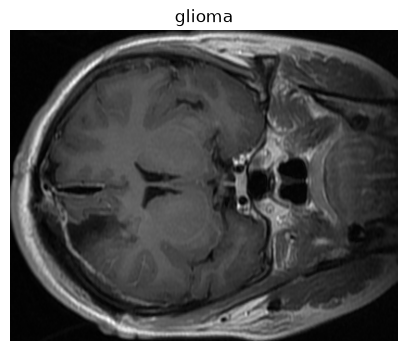

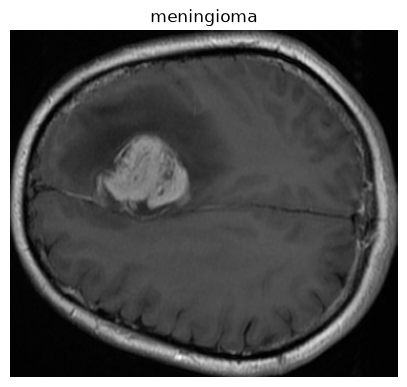

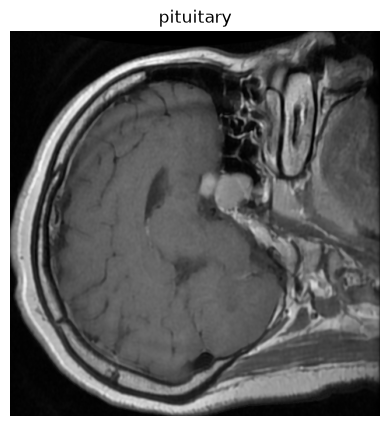

In [6]:
import random
import cv2
import matplotlib.pyplot as plt

for class_name in classes:

    folder = os.path.join(cropped_base, class_name)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ]

    filename = random.choice(files)
    path = os.path.join(folder, filename)

    img = cv2.imread(path)

    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis("off")
    plt.show()